In [1]:
import pandas as pd
import numpy as np 


n_smaples = 350

X = np.random.uniform(1,20,n_smaples)
noise  = np.random.normal(0,2000,n_smaples)

y = 1500 * X + noise + 10000

df = pd.DataFrame({'Years Experiance':X , 'Salary':y})
df.to_csv('LinearRegressionExample.csv', index=False)
print("File is already created")


File is already created


In [1]:
from mathcoreml.Models.linearRegression  import  linear_regression 
from mathcoreml.Models.logisticRegression import logistic_regression
from mathcoreml.utils.cleandata import cleandata 
from  mathcoreml.utils.csvstore import csvstore
from mathcoreml.utils.modelevalutaor import  RegressionEvaluator

In [2]:
linear_dataset = csvstore("/Users/tigran/Desktop/ML/MathCoreML/MathCoreML/LinearRegressionExample.csv")

Year Experiance  analyse
min :1.077648277382329
max:19.954207040983984
mean:10.611755617033028
moda:0       1.077648
1       1.093587
2       1.164138
3       1.186233
4       1.265702
         ...    
345    19.734648
346    19.788290
347    19.795786
348    19.877101
349    19.954207
Name: Years Experiance, Length: 350, dtype: float64
std:5.4213638586535975
Salary analyse
min of  Salary 7980.016142757087
max of  Salary 42087.29294452311
mean of  Salary 25863.411011626966
moda of  Salary 0       7980.016143
1       8913.835514
2      10102.688392
3      10111.329323
4      10244.093120
           ...     
345    40997.050863
346    41235.022472
347    41344.978046
348    41358.488983
349    42087.292945
Name: Salary, Length: 350, dtype: float64
std of  Salary 8462.404500939027


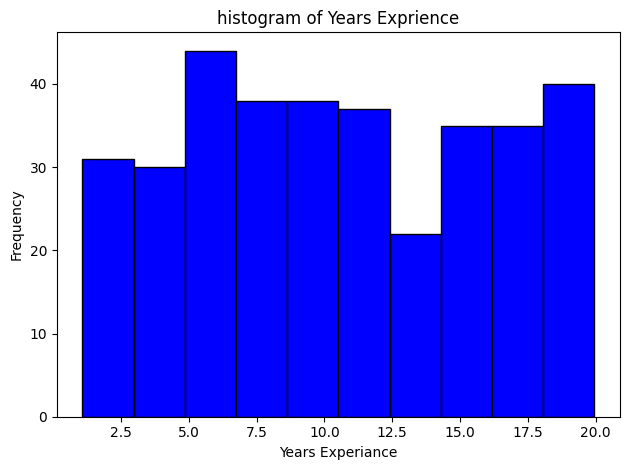

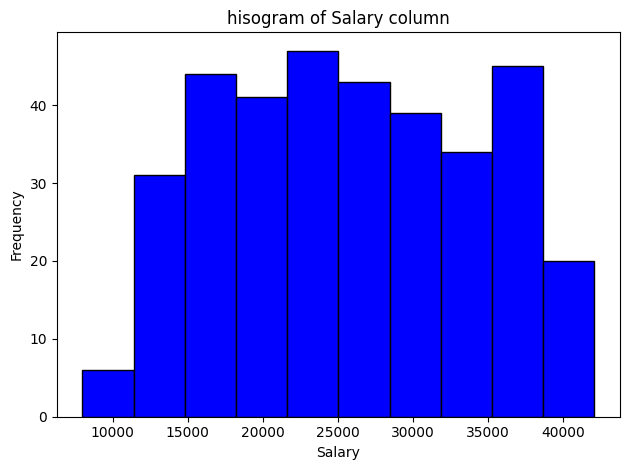

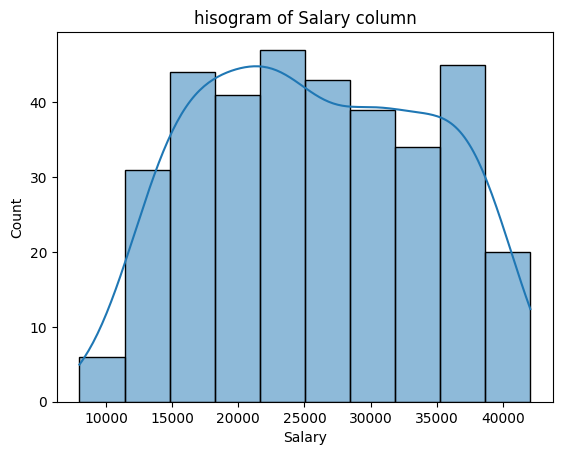

In [3]:
print("Year Experiance  analyse")
print(f"min :{linear_dataset.min_of('Years Experiance')}")
print(f"max:{linear_dataset.max_of('Years Experiance')}")
print(f"mean:{linear_dataset.mean_of('Years Experiance')}")
print(f"moda:{linear_dataset.mode_of('Years Experiance')}")
print(f"std:{linear_dataset.std_of('Years Experiance')}")
linear_dataset.histogram_of_one_column('Years Experiance','histogram of Years Exprience')


print("Salary analyse")
print(f"min of  Salary {linear_dataset.min_of('Salary')}")
print(f"max of  Salary {linear_dataset.max_of('Salary')}")
print(f"mean of  Salary {linear_dataset.mean_of('Salary')}")
print(f"moda of  Salary {linear_dataset.mode_of('Salary')}")
print(f"std of  Salary {linear_dataset.std_of('Salary')}")
linear_dataset.histogram_of_one_column("Salary",'hisogram of Salary column')
linear_dataset.histogram_of_one_column_sns("Salary",'hisogram of Salary column')


Correlation of Years Experiance and Salary = 0.9726529161477091


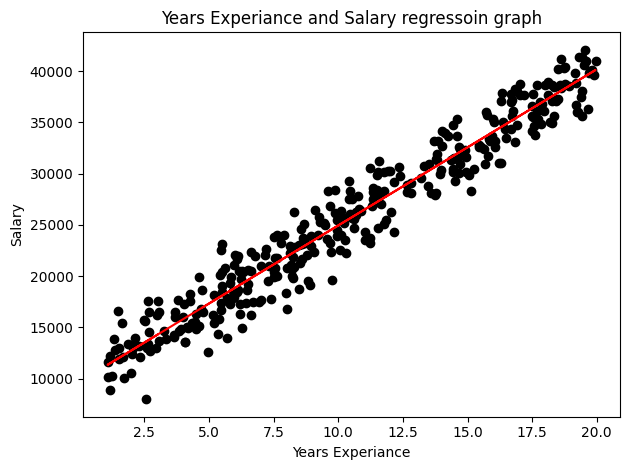

In [4]:
if linear_dataset.can_use_linear_regression("Years Experiance","Salary"):
    linear_regression_for_dataset = linear_regression(linear_dataset)
    linear_regression_for_dataset.preaper_data("Years Experiance","Salary")
    linear_regression_for_dataset.train_model()
    linear_regression_for_dataset.plot_regression()

In [5]:
heart_dataset = csvstore("/Users/tigran/Desktop/ML/MathCoreML/MathCoreML/Heart_Disease_Prediction.csv")

heart_dataset.head_of(5)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,700,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


In [6]:
logistic_reg = logistic_regression(heart_dataset)
logistic_reg.preaper_data('Heart Disease')
print(logistic_reg.train_model())

0.8333333333333334


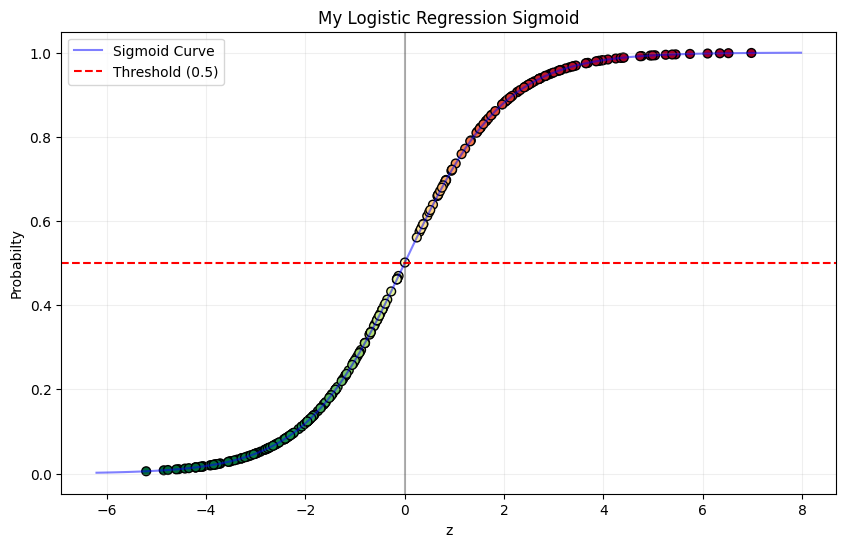

In [7]:
logistic_reg.plot_my_model_sigmoid()

In [29]:
predict = {}
for i in range(260,270):
    predict[logistic_reg.predict_single(i)] = (heart_dataset.frame.iloc[i])
    
df_results = pd.DataFrame(predict)
display(df_results)

,0.020945,0.991348,0.179467,0.027851,0.132207,0.236835,0.065941,0.123702,0.286150,0.993250
Age,58.0,60.0,58.0,49.0,48.0,52.0,44.0,56.0,57.0,67.0
Sex,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0
Chest pain type,3.0,4.0,2.0,2.0,2.0,3.0,2.0,2.0,4.0,4.0
BP,120.0,130.0,120.0,130.0,110.0,172.0,120.0,140.0,140.0,160.0
Cholesterol,340.0,206.0,284.0,266.0,229.0,199.0,263.0,294.0,192.0,286.0
FBS over 120,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
EKG results,0.0,2.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0
Max HR,172.0,132.0,160.0,171.0,168.0,162.0,173.0,153.0,148.0,108.0
Exercise angina,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
ST depression,0.0,2.4,1.8,0.6,1.0,0.5,0.0,1.3,0.4,1.5


In [16]:
print(heart_dataset.frame.iloc[260:270])

     Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
260   58    0                3  120          340             0            0   
261   60    1                4  130          206             0            2   
262   58    1                2  120          284             0            2   
263   49    1                2  130          266             0            0   
264   48    1                2  110          229             0            0   
265   52    1                3  172          199             1            0   
266   44    1                2  120          263             0            0   
267   56    0                2  140          294             0            2   
268   57    1                4  140          192             0            0   
269   67    1                4  160          286             0            2   

     Max HR  Exercise angina  ST depression  Slope of ST  \
260     172                0            0.0            1   
261     13

In [27]:
import pandas as pd
results_list = []

for i in range(260, 270):
    row_data = heart_dataset.frame.iloc[i].to_dict()
    row_data['Model_Prediction'] = logistic_reg.predict_single(i)
    results_list.append(row_data)

df_results = pd.DataFrame(results_list)

display(df_results)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease,Model_Prediction
0,58.0,0.0,3.0,120.0,340.0,0.0,0.0,172.0,0.0,0.0,1.0,0.0,3.0,0.0,0.020945
1,60.0,1.0,4.0,130.0,206.0,0.0,2.0,132.0,1.0,2.4,2.0,2.0,7.0,1.0,0.991348
2,58.0,1.0,2.0,120.0,284.0,0.0,2.0,160.0,0.0,1.8,2.0,0.0,3.0,1.0,0.179467
3,49.0,1.0,2.0,130.0,266.0,0.0,0.0,171.0,0.0,0.6,1.0,0.0,3.0,0.0,0.027851
4,48.0,1.0,2.0,110.0,229.0,0.0,0.0,168.0,0.0,1.0,3.0,0.0,7.0,1.0,0.132207
5,52.0,1.0,3.0,172.0,199.0,1.0,0.0,162.0,0.0,0.5,1.0,0.0,7.0,0.0,0.236835
6,44.0,1.0,2.0,120.0,263.0,0.0,0.0,173.0,0.0,0.0,1.0,0.0,7.0,0.0,0.065941
7,56.0,0.0,2.0,140.0,294.0,0.0,2.0,153.0,0.0,1.3,2.0,0.0,3.0,0.0,0.123702
8,57.0,1.0,4.0,140.0,192.0,0.0,0.0,148.0,0.0,0.4,2.0,0.0,6.0,0.0,0.286150
9,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1.0,0.993250
